In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
titanic_df = sns.load_dataset('titanic')
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [63]:
# Find total nuber of records
print(f'Total number of records: {len(titanic_df)}')

Total number of records: 891


In [64]:
missing_values_per_column = titanic_df.isna().sum(axis=0)

# Calculate the percentage of missing values for each column
print(missing_values_per_column / len(titanic_df) * 100)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [65]:
# Drop the 'deck' column since it has a high percentage of missing values
titanic_df.drop(columns=['deck'], inplace=True)

In [66]:
# These two columns seem to be redundant, let us investigate them 
titanic_df['survived'].unique(), titanic_df['alive'].unique()

(array([0, 1]), array(['no', 'yes'], dtype=object))

In [67]:
# Check if they differ in any record
(titanic_df['alive'].map({'yes': 1, 'no': 0}) != titanic_df['survived']).sum()

np.int64(0)

In [68]:
# Drop the 'survived' column as it just a duplicate of 'alive'
titanic_df.drop(columns=['survived'], inplace=True)

### Investigation of Sex Attribute

In [92]:
# Show the distribution of 'sex' column
titanic_df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

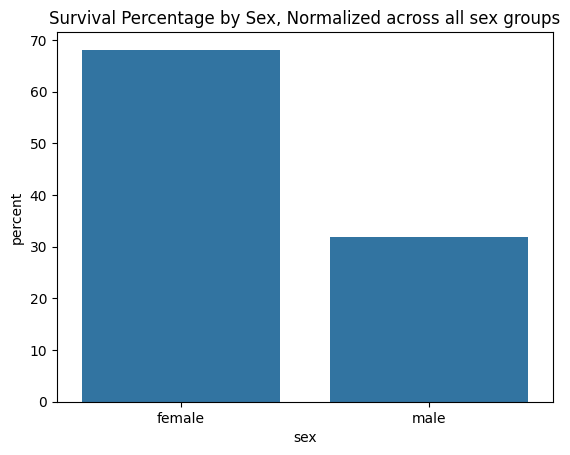

In [93]:
# Plot percentage of survivors by 'sex'
sns.countplot(data=titanic_df[titanic_df['alive'] == 'yes'], x='sex', stat='percent')
plt.title('Survival Percentage by Sex, Normalized across all sex groups')
plt.show() 

Notice that all bars sum up to 100. So we are not able to answer things like what proportion of men survived relative to the total men onboard. We shall use `pd.crosstab` function for such analysis.

In [71]:
percent_by_sex_group = pd.crosstab(titanic_df['sex'], titanic_df['alive'], normalize='index') * 100
percent_by_sex_group

alive,no,yes
sex,,
female,25.796178,74.203822
male,81.109185,18.890815


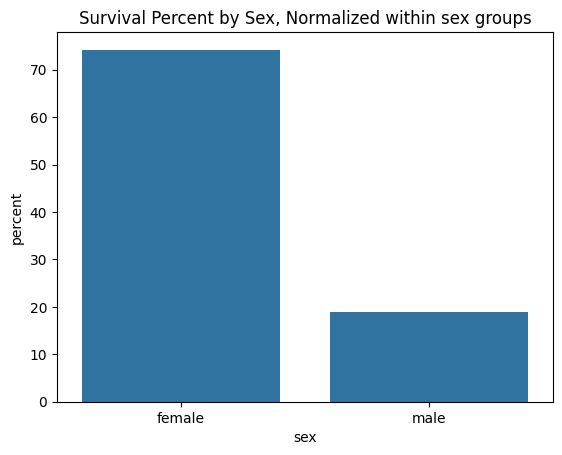

In [72]:
# Plot the percentage of survivors by 'sex' using a bar plot, with normalization within each 'sex' group
sns.barplot(data=percent_by_sex_group, x=percent_by_sex_group.index, y='yes')
plt.title('Survival Percentage by Sex, Normalized within sex groups')
plt.ylabel('percent')
plt.show()

Women had a much higher survival rate as compared to men.

### Investigation of Who Attribute

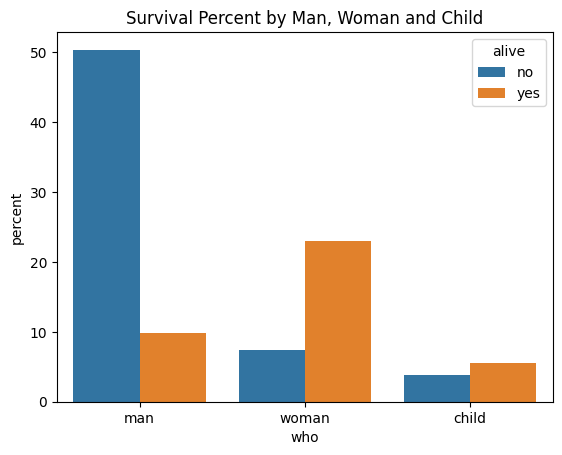

In [73]:
# Plot the percentage of survivors by 'who'
sns.countplot(data=titanic_df, x='who', hue='alive', stat='percent')
plt.title('Survival Percent by Man, Woman and Child')
plt.show()

In [74]:
percentage_by_who_group = pd.crosstab(titanic_df['who'], titanic_df['alive'], normalize='index') * 100
percentage_by_who_group

alive,no,yes
who,,
child,40.963855,59.036145
man,83.612663,16.387337
woman,24.354244,75.645756


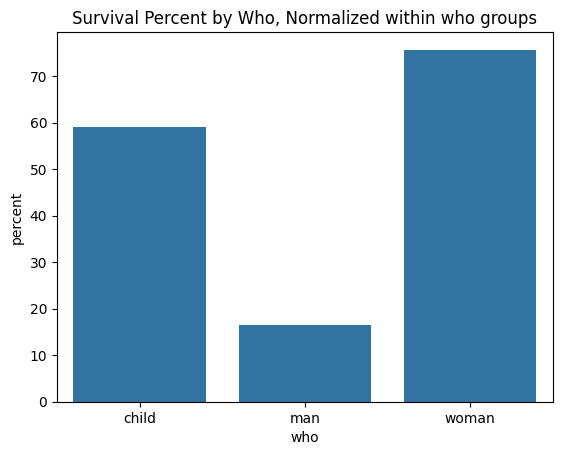

In [75]:
sns.barplot(data=percentage_by_who_group, x=percentage_by_who_group.index, y='yes')
plt.title('Survival Percent by Who, Normalized within who groups')
plt.ylabel('percent')
plt.show()

Clearly, most women survived followed by children. Poor men.

### Investigation of Class and Fare Attribute

In [76]:
# Let us look at the unique values and their counts
titanic_df['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

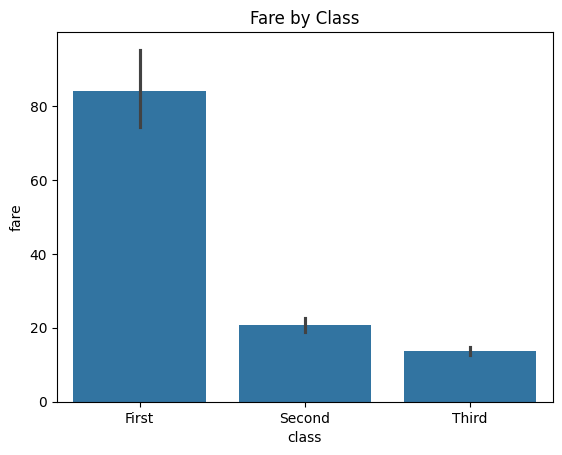

In [80]:
# Let us see how fare and class are related using a bar plot
sns.barplot(data=titanic_df, x='class', y='fare')
plt.title('Fare by Class: Barplot')
plt.show()

Obviously, first class people were paying the largest fare.  
The height of the bar represents the mean fare and the black line (called error bar) represents the $95\%$ confidence interval obtained by bootstrapping.

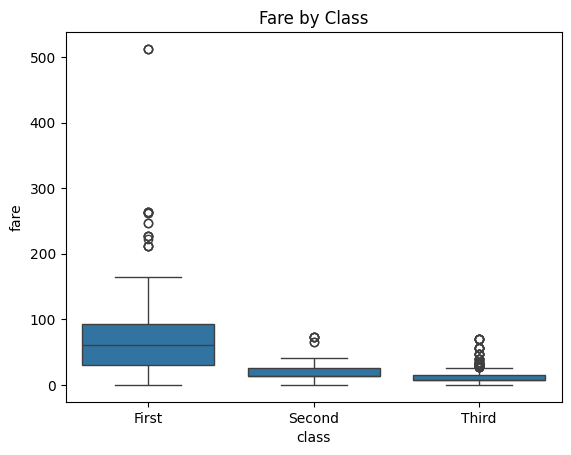

In [81]:
# Let us plot the boxplot as well to see the distribution more clearly
sns.boxplot(data=titanic_df, x='class', y='fare')
plt.title('Fare by Class: Boxplot')
plt.show()

There are some extreme outliers in the first class group, meaning some first class passengers were paying way too high. Let us see if they survived or not.

In [82]:
high_fare_threshold = titanic_df[titanic_df['class'] == 'First']['fare'].quantile(0.95)
print(f'95th percentile of fare for First class: {high_fare_threshold}')

num_people_with_high_fare = (titanic_df[titanic_df['class'] == 'First']['fare'] > high_fare_threshold).sum()
print(f'Number of people with fare above 95th percentile: {num_people_with_high_fare}')

num_people_with_high_fare_and_survived = ((titanic_df['class'] == 'First') & (titanic_df['fare'] > high_fare_threshold) & (titanic_df['alive'] == 'yes')).sum()
print(f'Number of people with fare above 95th percentile who survived: {num_people_with_high_fare_and_survived}')0

95th percentile of fare for First class: 232.52395
Number of people with fare above 95th percentile: 11
Number of people with fare above 95th percentile who survived: 8


Seems like if you paid well, you were pretty likely to have survived, coincidence maybe. Let us dive deeper.

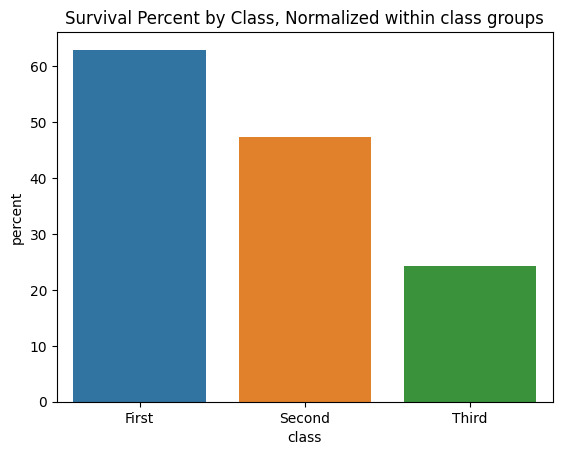

In [85]:
percent_by_class_group = pd.crosstab(titanic_df['class'], titanic_df['alive'], normalize='index') * 100
sns.barplot(data=percent_by_class_group, x=percent_by_class_group.index, y='yes', hue=percent_by_class_group.index)
plt.title('Survival Percentange by Class, Normalized within class groups')
plt.ylabel('percent')
plt.show()

Survival rate of first class passengers was the highest, followed by second and third class respectively.

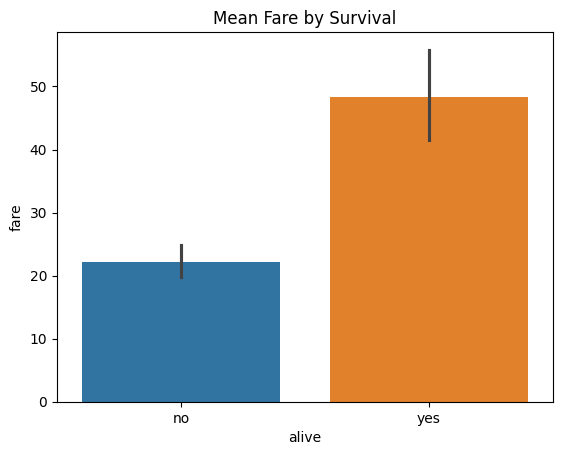

In [102]:
# Let us the mean fare for the two groups of survivors and non-survivors
sns.barplot(data=titanic_df, x='alive', y='fare', hue='alive')
plt.title('Mean Fare by Survival')
plt.show()

In [101]:
# Let us look at some more stats
fare_stats_by_survival = titanic_df.groupby('alive').agg(
    mean=('fare', 'mean'),
    median=('fare', 'median'),
    count=('fare', 'count'),
    std=('fare', 'std') 
)
fare_stats_by_survival

,mean,median,count,std
alive,,,,
no,22.117887,10.5,549,31.388207
yes,48.395408,26.0,342,66.596998


The mean fare of the passengers who survived was almost twice as that of the passengers who did not. Same lines hold for median fare as well. There was a greater variablilty in the fares of the people who survived, probably due the the greater variability in the fares first class gruop.

### Investigation of Age Attribute

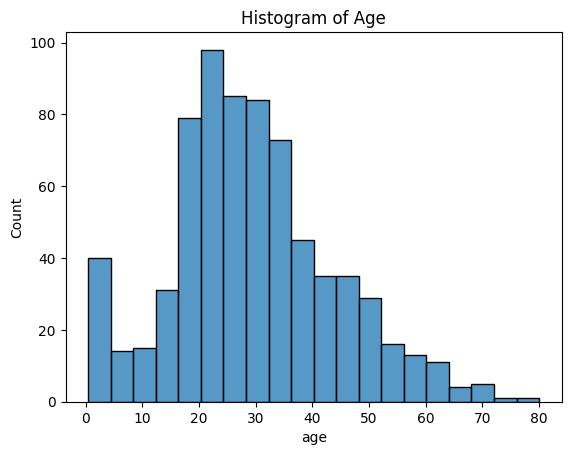

In [106]:
# Let us start by plotting the histogram of the age column
sns.histplot(data=titanic_df, x='age')
plt.title('Histogram of Age')
plt.show()

The initial bucket represents babies/toddlers. Age has right-skewed distribution.

In [107]:
# Let us look at more age related stats
titanic_df['age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

The mean and median are pretty close. So the skew is not as bad as it looks.

In [108]:
# Let us look the the exact skewness
titanic_df['age'].skew()

np.float64(0.38910778230082704)

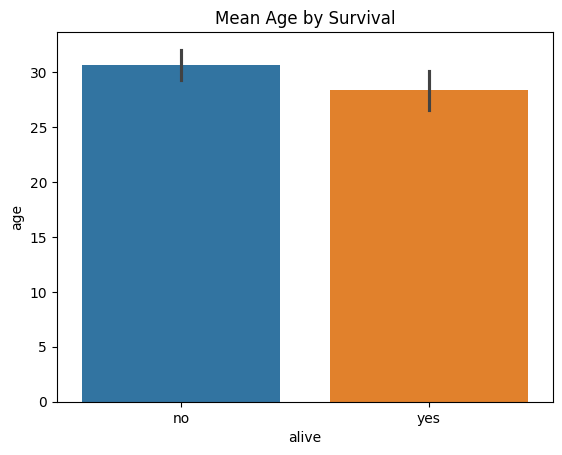

In [109]:
# Let us look at mean age by survival
sns.barplot(data=titanic_df, x='alive', y='age', hue='alive')
plt.title('Mean Age by Survival')
plt.show()